# Predicting Cylinder Gas Spend at UCSF 
<font face="serif">UCSF relies on a steady and consistent supply of industrial gases to execute the mission of teaching, research, and public service. Without a supply of gases, UCSF wouldn't have oxygen for patients, nitrogen to keep our samples frozen, or helium for the balloons in the hospital gift shop. Ok, the last one isnt as important, but everyone likes balloons, right?

Given the importance to research of this important supply (sorry balloon people), in 2017 the Chief Procurement Officer, Director of Logistics and Director of Strategic Sourcing decided to forecast demand and work with our suppliers to better manage our supply chain. This includes staging inventory at strategic locations within the supply chain, optimizing ordering/re-ordering, and otherwise reducing risk.

<font face="serif">Facebook Prophet can do the forecasting and Pandas can handle the data and provide analytic simplicity for us (thanks Wes!).  

In [1]:
import pandas as pd
from fbprophet import Prophet
%matplotlib inline

### Data Formatting
<font face='serif'>The data available for this analysis is a simple daily transaction report. It identifies each individual recharge transferred from campus departments to central receiving to pay for gases. Central receiving then pays the gas company and delivers the gases to campus. Its worth noting that this recharge and central distribution operation helps keep trucks off the roads at our Urban UCSF campuses, something I am certain the neighbors appreciate. The data spans multiple years and was pre-processed to eliminate price fluctuations, putting everything into current year dollars and allowing for accurate forecast.

The data is read-in using Pandas, which permits parsing dates, setting the frame index and generating descriptive stats.

In [2]:
sales = pd.read_csv('~/Desktop/BasicSales.csv', parse_dates=[0], index_col=[0])
print(sales.describe())
sales.head()


               Spend
count  123467.000000
mean       14.152026
std        46.376646
min         0.010000
25%         4.590000
50%         4.820000
75%         4.820000
max      3197.350000


,Spend
Date,
2016-07-05,12.70
2016-07-05,12.70
2016-07-13,25.40
2016-07-19,38.10
2016-07-12,17.82


### Data Transforms

<font face='serif'>Aggregation into daily, monthly, or quarterly time periods will greatly improve the signal to noise ratio of the data allowing us to build a better forecast.  Pandas' built in re-sample functionality allows us to accomplish this efficiently. 

One squirrelly thing that popped up is that Prophet requires a specific format for the data including column names of "ds" and "y" respectively.  A simple line of pandas code to rename the columns did the trick and resetting the index helped as well. 

<font face='serif'>A description of the transformed dataset shows 34 months vs. 123k transactions and is an indication of successful transformation.  

In [3]:
sales = sales.resample('M').sum().reset_index()
sales = sales.rename(columns={'Spend': 'y', 'Date': 'ds'})
print(sales.describe())
sales.head()

                  y
count     34.000000
mean   51391.416176
std     5999.418426
min    39895.430000
25%    47197.010000
50%    52560.505000
75%    54708.455000
max    64182.360000


,ds,y
0,2014-07-31,47589.77
1,2014-08-31,52562.17
2,2014-09-30,43379.17
3,2014-10-31,49140.35
4,2014-11-30,39895.43


### Forecasting

<font face='serif'>The syntax of fbprophet is similar to that of Scikit learn in that we instantiate a Prophet object, which I non-creatively called _m_, and then _fit_ the model to our data, creating all the necessary coefficients to forecast our model.  Notice that Prophet is smart enough to know the data is monthly and it automatically disabled weekly seasonality for us.  Thanks FB!

In [4]:
m = Prophet()
m.fit(sales);

Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.


<font face='serif'>At this point, we are ready to begin predicting future months.  To do so, first create a dataframe of dates that will hold our forecaster sales.  Again, I was very creative and named this variable _future_.  Notice that the  _make future dataframe_ allows us to quickly generate that variable.  

With our _future_ dataframe in hand, we now use our Prophet instance _m_ to _predict_, creating a _forecast_ dataframe to hold all the resulting data.  

In [5]:
future = m.make_future_dataframe(periods=18, freq='M')
future.tail()

forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2014-07-31,46248.000210,43230.814289,49849.367929
1,2014-08-31,46227.145702,42892.859614,49289.770243
2,2014-09-30,44206.675369,41075.184788,47539.057558
3,2014-10-31,48419.904168,45193.054064,51727.680646
4,2014-11-30,41546.723615,38322.246351,44573.853222


### Plotting

<font face='serif'>Ok, so how accurate is the forecast? One of the most convenient features of Prophet is the plotting capability.  With 2 lines of code we can get presentation quality plots of the forecast and the various components of the forecast.

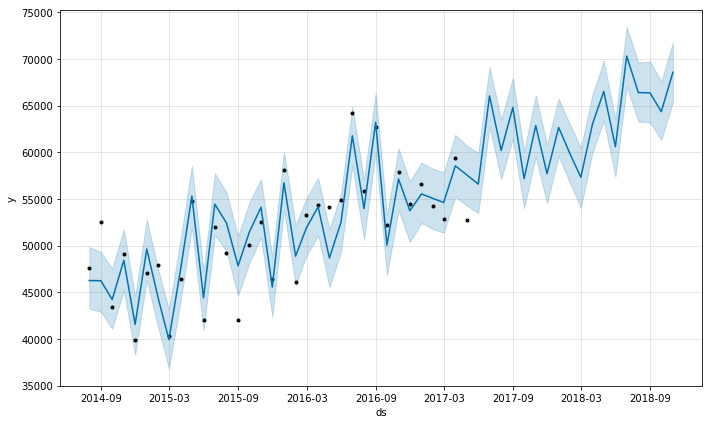

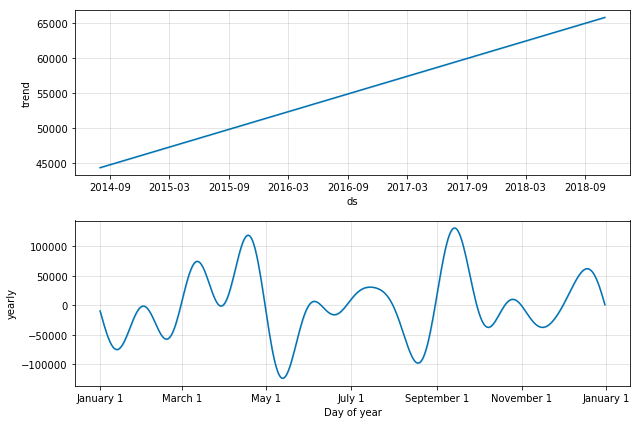

In [6]:
m.plot(forecast);
m.plot_components(forecast);

### Do Holiday's Matter?

<font face='serif'>Prophet also gives us the ability to consider holiday's in our forecasting. We do this by first creating a dataframe of all holidays (past, present, and future).  Honestly, this is not trivial given that finding the non-working days back to the beginning of the dataset is manual.  Be that as it may, it's a fun exercise to see whether the inclusion of holiday's impact the overall forecast.  

In [7]:
holidays = pd.DataFrame({
    'holiday' : 'NonWorkDay',
    'ds': pd.to_datetime(['2013-07-04','2013-09-02',
                          '2013-11-11','2013-11-28',
                          '2013-11-29','2013-12-24',
                          '2013-12-25','2013-12-31',
                          '2014-01-01','2014-01-20',
                          '2014-02-17','2014-03-28',
                          '2014-05-26','2014-07-04',
                          '2014-09-01','2014-11-11',
                          '2014-11-27','2014-11-28',
                          '2014-12-25','2014-12-26',
                          '2014-12-31','2015-01-01',
                          '2015-01-19','2015-02-16',
                          '2015-03-27','2015-05-26',
                          '2015-07-04','2015-09-07',
                          '2015-11-11','2015-11-26',
                          '2015-11-27','2015-12-24',
                          '2015-12-25','2015-12-31',
                          '2016-01-01','2016-01-18',
                          '2016-02-15','2016-03-25',
                          '2016-05-30','2016-07-04',
                          '2016-09-05','2016-11-11',
                          '2016-11-24','2016-11-25',
                          '2016-12-23','2016-12-26',
                          '2016-12-30','2017-01-02',
                          '2017-01-16','2017-02-20',
                          '2017-03-31','2017-05-29',
                          '2017-07-04','2017-09-04',
                          '2017-11-10','2017-11-23',
                          '2017-11-24','2017-12-25',
                          '2017-12-26','2017-12-29',
                          '2018-01-01','2018-01-15',
                          '2018-02-19','2018-03-30',
                          '2018-05-28','2018-07-04',
                          '2018-09-03','2018-11-12',
                          '2018-11-22','2018-11-23',
                          '2018-12-24','2018-12-25',
                          '2018-12-31','2019-01-01',
                          '2019-01-21','2019-02-18',
                          '2019-03-29','2019-05-27']),
  'lower_window': -1,
  'upper_window': 1,
})

<font face='serif'>After creating a dataframe of all the UCSF holidays, we then create a new instance of Prophet, this time referencing our holiday dataframe.  We then fit the model as we did previously and run the charts as we did above.  

In [8]:
m = Prophet(holidays=holidays)
forecast = m.fit(sales).predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.


,ds,yhat,yhat_lower,yhat_upper
0,2014-07-31,45956.761857,43201.156468,48540.689710
1,2014-08-31,52548.542407,49682.355715,55292.755030
2,2014-09-30,44115.310206,41302.174889,46826.430026
3,2014-10-31,48362.522867,45698.951107,50981.259774
4,2014-11-30,41499.392253,38691.271688,44244.246561


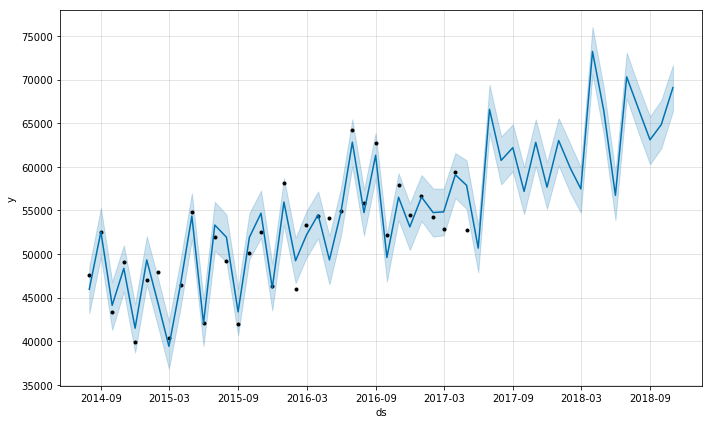

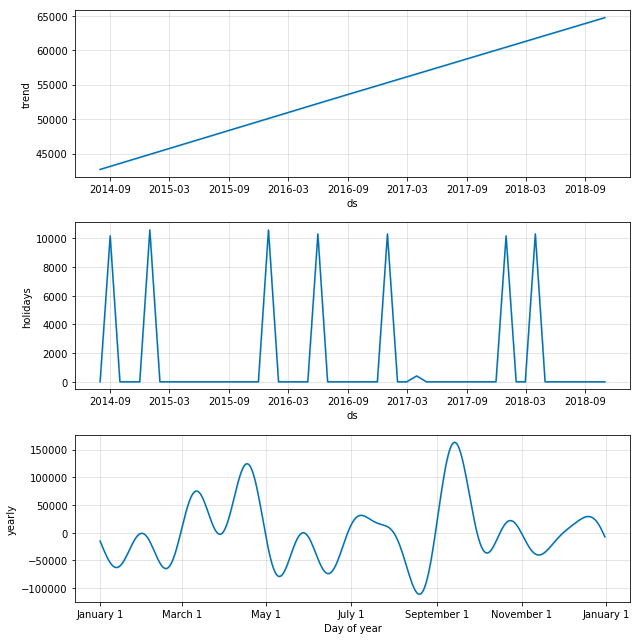

In [9]:
m.plot(forecast);
m.plot_components(forecast);

<font face='serif'>We can also review the impact the holidays have on the forecast.  

In [10]:
forecast[(forecast['NonWorkDay']).abs() > 0][
        ['ds', 'NonWorkDay']][-10:]


,ds,NonWorkDay
1,2014-08-31,10176.547829
5,2014-12-31,10588.409768
17,2015-12-31,10588.409768
22,2016-05-31,10308.806729
29,2016-12-31,10308.806729
32,2017-03-31,411.861939
41,2017-12-31,10176.547829
44,2018-03-31,10308.806729


### Conclusion

<font face='serif'>This code allows us to forecast out the expected need for gas at UCSF.  We can use these forecasts to collaborate with suppliers, to stage inventory, or simply to for effective budgeting.  Facebook Prophet streamlined the process and reducing both the time and skill requirements to conduct forecasting.  

In [11]:
forecast.to_csv('~/Desktop/salesForecast.csv')